# Fusion : Méthode statistique + Autoencodeur

In [1]:
import pandas as pd
import numpy as np

print("="*70)
print("ÉTAPE 1 : HARMONISATION TEMPORELLE (OPTIMISÉE MÉMOIRE)")
print("="*70)

# Charger la Shadow Story (léger)
df_story = pd.read_csv('outputs_stats/shadow_story_fusion.csv')

# Charger les données statistiques (léger)
df_stat = pd.read_csv('outputs_stats/stat_annotated_timeseries.csv')
df_stat['timestamp'] = pd.to_datetime(df_stat['timestamp'])

print("\n🔍 DIAGNOSTIC DES DONNÉES SOURCES :")
print("\n📊 STATISTIQUE :")
print(f"  • Lignes : {len(df_stat)}")
print(f"  • Période : {df_stat['timestamp'].min()} → {df_stat['timestamp'].max()}")
if 'anomaly_detected' in df_stat.columns:
    print(f"  • Anomalies détectées : {df_stat['anomaly_detected'].sum()}")
    print(f"  • Taux d'anomalie : {df_stat['anomaly_detected'].mean()*100:.2f}%")
else:
    print("  ⚠️ ATTENTION : Colonne 'anomaly_detected' manquante!")

# Choisir résolution commune : 15 minutes
freq = '15min'

# Ré-échantillonner statistique
df_stat_resampled = df_stat.set_index('timestamp').resample(freq).agg({
    'anomaly_detected': 'max',
    'shadow_score': 'mean',
    'cluster_id': 'first',
    'hour_of_day': 'first'
}).reset_index()

print(f"\n✅ Statistique après resampling : {len(df_stat_resampled)} points")
print(f"   • Anomalies conservées : {df_stat_resampled['anomaly_detected'].sum()}")

# === TRAITEMENT AUTO-ENCODEUR PAR CHUNKS (OPTIMISATION MÉMOIRE) ===
print("\n📊 AUTO-ENCODEUR (traitement par chunks) :")

# Lire en chunks pour éviter surcharge mémoire
chunk_size = 1_000_000
df_ae_resampled_list = []

for chunk_idx, chunk in enumerate(pd.read_csv('ae_annotated_timeseries.csv', chunksize=chunk_size)):
    print(f"  • Traitement chunk {chunk_idx + 1} ({len(chunk)} lignes)...", end=' ')
    
    # Convertir timestamp
    chunk['timestamp'] = pd.to_datetime(chunk['timestamp'])
    
    # Renommer colonnes
    chunk['anomaly_ae'] = chunk['anomaly_detected']
    chunk['error_normalized'] = chunk['anomaly_score']
    
    # Resample ce chunk
    chunk_resampled = chunk.set_index('timestamp').resample(freq).agg({
        'reconstruction_error': 'mean',
        'anomaly_ae': 'max',
        'error_normalized': 'mean'
    }).reset_index()
    
    df_ae_resampled_list.append(chunk_resampled)
    print(f"✓ ({len(chunk_resampled)} points après resample)")

# Concaténer et ré-agréger (au cas où un timestamp apparaît dans plusieurs chunks)
print("  • Fusion des chunks...", end=' ')
df_ae_resampled = pd.concat(df_ae_resampled_list, ignore_index=True)

# Re-grouper par timestamp pour fusionner les doublons
df_ae_resampled = df_ae_resampled.groupby('timestamp').agg({
    'reconstruction_error': 'mean',
    'anomaly_ae': 'max',
    'error_normalized': 'mean'
}).reset_index()

print(f"✓")
print(f"\n✅ AE après resampling : {len(df_ae_resampled)} points")
print(f"   • Anomalies conservées : {df_ae_resampled['anomaly_ae'].sum()}")

# === FUSION DES DEUX DATAFRAMES ===
print("\n🔗 Fusion des données...", end=' ')
df_master = df_stat_resampled.merge(
    df_ae_resampled,
    on='timestamp',
    how='outer',
    suffixes=('_stat', '_ae')
).sort_values('timestamp')

# Remplir les NaN
df_master['anomaly_detected'] = df_master['anomaly_detected'].fillna(0).astype(int)
df_master['anomaly_ae'] = df_master['anomaly_ae'].fillna(0).astype(int)
df_master['shadow_score'] = df_master['shadow_score'].fillna(0)
df_master['error_normalized'] = df_master['error_normalized'].fillna(0)
df_master['reconstruction_error'] = df_master['reconstruction_error'].fillna(0)

print(f"✓")
print(f"\n✅ DataFrame maître créé : {len(df_master)} points à résolution {freq}")
print(f"Colonnes : {df_master.columns.tolist()}")

print("\n" + "="*70)



ÉTAPE 1 : HARMONISATION TEMPORELLE (OPTIMISÉE MÉMOIRE)

🔍 DIAGNOSTIC DES DONNÉES SOURCES :

📊 STATISTIQUE :
  • Lignes : 15863474
  • Période : 2017-11-01 00:00:00 → 2024-11-01 23:55:00
  • Anomalies détectées : 1270005
  • Taux d'anomalie : 8.01%

✅ Statistique après resampling : 245568 points
   • Anomalies conservées : 98619.0

📊 AUTO-ENCODEUR (traitement par chunks) :
  • Traitement chunk 1 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 2 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 3 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 4 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 5 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 6 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 7 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement chunk 8 (1000000 lignes)... ✓ (245568 points après resample)
  • Traitement ch

In [2]:
print("\n" + "="*70)
print("ÉTAPE 2 : CALCUL DES 8 FEATURES DE FUSION")
print("="*70)

# Jointure avec Shadow Story pour avoir les métadonnées de cluster
df_master = df_master.merge(
    df_story[['cluster_id', 'taux_recurrence', 'intensite_moyenne_pct', 
              'heure_debut', 'heure_fin', 'nb_jours_actifs']],
    on='cluster_id',
    how='left'
)

# --- FEATURES DU STATISTIQUE ---

# Feature 1: Persistance du cluster
df_master['feat_persistance_cluster'] = df_master['taux_recurrence'].fillna(0)

# Feature 2: Proximité heure typique (timestamp dans la plage horaire du cluster?)
def is_in_typical_hours(row):
    if pd.isna(row['heure_debut']) or pd.isna(row['heure_fin']):
        return 0
    hour = row['timestamp'].hour
    h_debut = int(row['heure_debut'].split(':')[0])
    h_fin = int(row['heure_fin'].split(':')[0])
    return 1 if h_debut <= hour <= h_fin else 0

df_master['feat_proximite_heure_typique'] = df_master.apply(is_in_typical_hours, axis=1)

# Feature 3: Densité du cluster (nb de jours actifs comme proxy)
df_master['feat_densite_cluster'] = df_master['nb_jours_actifs'].fillna(0) / 90  # Normaliser sur 3 mois

# --- FEATURES DE L'AUTO-ENCODEUR ---

# Feature 4: Intensité de l'erreur (déjà normalisée)
df_master['feat_error_intensity'] = df_master['error_normalized']

# Feature 5: Durée de l'événement (calculée via groupement)
# Grouper les anomalies AE consécutives
df_master['ae_group'] = (df_master['anomaly_ae'] != df_master['anomaly_ae'].shift()).cumsum()
event_durations = df_master[df_master['anomaly_ae'] == 1].groupby('ae_group').size() * 15  # minutes
df_master['feat_event_duration'] = df_master['ae_group'].map(event_durations).fillna(0)

# Feature 6: Brutalité du gradient (vitesse de montée de l'erreur)
df_master['error_diff'] = df_master['reconstruction_error'].diff()
df_master['feat_gradient_brutality'] = df_master['error_diff'].abs().fillna(0)

# --- FEATURES CROISÉES ---

# Feature 7: Concordance (les deux modèles détectent simultanément?)
df_master['feat_concordance'] = np.where(
    (df_master['anomaly_detected'] == 1) & (df_master['anomaly_ae'] == 1),
    1, 0
)

# Feature 8: Heure de la journée
df_master['feat_hour_of_day'] = df_master['timestamp'].dt.hour

print("✅ 8 Features calculées :")
print("   [1] feat_persistance_cluster")
print("   [2] feat_proximite_heure_typique")
print("   [3] feat_densite_cluster")
print("   [4] feat_error_intensity")
print("   [5] feat_event_duration")
print("   [6] feat_gradient_brutality")
print("   [7] feat_concordance")
print("   [8] feat_hour_of_day")


ÉTAPE 2 : CALCUL DES 8 FEATURES DE FUSION
✅ 8 Features calculées :
   [1] feat_persistance_cluster
   [2] feat_proximite_heure_typique
   [3] feat_densite_cluster
   [4] feat_error_intensity
   [5] feat_event_duration
   [6] feat_gradient_brutality
   [7] feat_concordance
   [8] feat_hour_of_day


In [3]:
print("\n" + "="*70)
print("ÉTAPE 3 : FUSION PAR RÈGLES EXPERTES (TABLEAU DE DÉCISION)")
print("="*70)

def fusion_rules_expert(row):
    """
    Applique le tableau de décision exact du document.
    
    Retourne: (type_alerte, confiance)
    """
    stat = row['anomaly_detected']
    ae = row['anomaly_ae']
    persistance = row['feat_persistance_cluster']
    duree = row['feat_event_duration']
    
    # CAS 1: ✅ Stat ET ✅ AE
    if stat == 1 and ae == 1:
        if persistance > 0.70:
            return "Ombrage Fixe Confirmé", 95
        elif persistance >= 0.30:
            return "Ombrage Fixe Modéré", 85
        else:
            return "Ombrage Fixe Modéré", 85  # Pas explicite dans table, on garde 85
    
    # CAS 2: ✅ Stat MAIS ❌ AE
    if stat == 1 and ae == 0:
        if persistance > 0.70:
            return "Ombrage Fixe Léger", 75
        else:
            return "Faux Positif Potentiel", 40
    
    # CAS 3: ❌ Stat MAIS ✅ AE
    if stat == 0 and ae == 1:
        if duree < 120:  # < 2h
            return "Événement Ponctuel", 85
        else:
            return "Ombrage Émergent Non Capté", 60
    
    # CAS 4: ❌ Stat ET ❌ AE
    return "Normal", 0

# Application des règles
result = df_master.apply(fusion_rules_expert, axis=1, result_type='expand')
df_master['type_alerte'] = result[0]
df_master['confiance'] = result[1]

# Statistiques
print("\n📊 DISTRIBUTION DES ALERTES :")
print(df_master['type_alerte'].value_counts())



ÉTAPE 3 : FUSION PAR RÈGLES EXPERTES (TABLEAU DE DÉCISION)

📊 DISTRIBUTION DES ALERTES :
type_alerte
Normal                        135128
Faux Positif Potentiel         86319
Ombrage Fixe Modéré            12300
Événement Ponctuel              6368
Ombrage Émergent Non Capté      5473
Name: count, dtype: int64


In [4]:
print("\n" + "="*70)
print("ÉTAPE 4 : FUSION PAR MACHINE LEARNING (XGBoost - Optionnel)")
print("="*70)

# Installation dans l'environnement du kernel actuel
import sys
import subprocess

try:
    import xgboost as xgb
    print("✅ XGBoost déjà installé")
except ImportError:
    print("📦 Installation de XGBoost dans l'environnement du kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb
    print("✅ XGBoost installé avec succès")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("\n🤖 Préparation du modèle XGBoost...")

# === CONSTRUCTION DES 12 FEATURES ===
print("\n📊 Construction des 12 features pour XGBoost:")

# Features déjà calculées (8)
feature_cols = [
    'feat_persistance_cluster',      # 1
    'feat_proximite_heure_typique',  # 2
    'feat_densite_cluster',           # 3
    'feat_error_intensity',           # 4
    'feat_event_duration',            # 5
    'feat_gradient_brutality',        # 6
    'feat_concordance',               # 7
    'feat_hour_of_day'                # 8
]

# Features additionnelles (4)
df_master['feat_score_stat'] = df_master['shadow_score']  # 9
df_master['feat_score_ae'] = df_master['error_normalized']  # 10
df_master['feat_day_of_year'] = df_master['timestamp'].dt.dayofyear  # 11
df_master['feat_cluster_id_encoded'] = LabelEncoder().fit_transform(
    df_master['cluster_id'].fillna(-1).astype(str)
)  # 12

feature_cols += ['feat_score_stat', 'feat_score_ae', 'feat_day_of_year', 'feat_cluster_id_encoded']

print(f"✅ 12 features construites: {len(feature_cols)}")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

# === PRÉPARATION DES LABELS (SEMI-SUPERVISÉ) ===
print("\n🏷️  Création des labels d'entraînement (basés sur règles expertes):")

# Mapper les décisions expertes en classes numériques
label_mapping = {
    'Normal': 0,
    'Faux Positif Potentiel': 0,  # Considéré comme Normal
    'Événement Ponctuel': 2,
    'Ombrage Émergent Non Capté': 3,
    'Ombrage Fixe Léger': 1,
    'Ombrage Fixe Modéré': 1,
    'Ombrage Fixe Confirmé': 1
}

df_master['label'] = df_master['type_alerte'].map(label_mapping)

print("Classes définies:")
print("  0 → Normal")
print("  1 → Ombrage Fixe")
print("  2 → Événement Ponctuel")
print("  3 → Incertain (inspection requise)")

# === SPLIT TRAIN/TEST ===
X = df_master[feature_cols].fillna(0)
y = df_master['label']

# Utiliser 70% pour l'entraînement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📈 Split des données:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Test:  {len(X_test):,} samples")
print(f"\n  Distribution train: {y_train.value_counts().to_dict()}")

# === ENTRAÎNEMENT XGBOOST ===
print("\n🚀 Entraînement du modèle XGBoost...")

model_xgb = xgb.XGBClassifier(
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ Modèle entraîné!")

# === PRÉDICTIONS ===
print("\n🔮 Prédictions sur l'ensemble complet...")

# Prédictions avec probabilités
y_pred_proba = model_xgb.predict_proba(X)
y_pred = model_xgb.predict(X)

df_master['classe_xgb'] = y_pred
df_master['confiance_xgb'] = y_pred_proba.max(axis=1) * 100  # Convertir en %

# Mapper les classes numériques vers noms
class_names = {0: 'Normal', 1: 'Ombrage Fixe', 2: 'Événement Ponctuel', 3: 'Incertain'}
df_master['type_alerte_xgb'] = df_master['classe_xgb'].map(class_names)

print(f"✅ Prédictions complétées!")

# === COMPARAISON RÈGLES VS ML ===
print("\n" + "="*70)
print("📊 COMPARAISON RÈGLES EXPERTES vs XGBoost")
print("="*70)

print("\n1️⃣  Distribution des décisions (Règles Expertes):")
print(df_master['type_alerte'].value_counts())

print("\n2️⃣  Distribution des décisions (XGBoost):")
print(df_master['type_alerte_xgb'].value_counts())

# Concordance
concordance_ml = (df_master['label'] == df_master['classe_xgb']).sum()
print(f"\n🎯 Concordance Règles ↔ XGBoost: {concordance_ml/len(df_master)*100:.1f}%")

# Importance des features
print("\n📊 Top 5 Features les plus importantes (XGBoost):")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")

# === DÉCISION FINALE (HYBRIDE) ===
print("\n🔀 Décision finale hybride (Règles + ML):")
print("   → Prendre XGBoost SI confiance > 80%, SINON garder règles expertes")

df_master['type_alerte_final'] = np.where(
    df_master['confiance_xgb'] > 80,
    df_master['type_alerte_xgb'],
    df_master['type_alerte']
)

df_master['confiance_final'] = np.where(
    df_master['confiance_xgb'] > 80,
    df_master['confiance_xgb'],
    df_master['confiance']
)

print("\n3️⃣  Distribution des décisions (HYBRIDE):")
print(df_master['type_alerte_final'].value_counts())

print("\n✅ Fusion ML complétée!")



ÉTAPE 4 : FUSION PAR MACHINE LEARNING (XGBoost - Optionnel)
✅ XGBoost déjà installé

🤖 Préparation du modèle XGBoost...

📊 Construction des 12 features pour XGBoost:
✅ 12 features construites: 12
    1. feat_persistance_cluster
    2. feat_proximite_heure_typique
    3. feat_densite_cluster
    4. feat_error_intensity
    5. feat_event_duration
    6. feat_gradient_brutality
    7. feat_concordance
    8. feat_hour_of_day
    9. feat_score_stat
   10. feat_score_ae
   11. feat_day_of_year
   12. feat_cluster_id_encoded

🏷️  Création des labels d'entraînement (basés sur règles expertes):
Classes définies:
  0 → Normal
  1 → Ombrage Fixe
  2 → Événement Ponctuel
  3 → Incertain (inspection requise)

📈 Split des données:
  Train: 171,911 samples
  Test:  73,677 samples

  Distribution train: {0: 155012, 1: 8610, 2: 4458, 3: 3831}

🚀 Entraînement du modèle XGBoost...
✅ Modèle entraîné!

🔮 Prédictions sur l'ensemble complet...
✅ Prédictions complétées!

📊 COMPARAISON RÈGLES EXPERTES vs XGB

In [5]:
print("\n" + "="*70)
print("ÉTAPE 5 : POST-TRAITEMENT ET AGRÉGATION")
print("="*70)

# A. Lissage temporel : Supprimer détections isolées < 5 minutes
df_master['alert_group'] = (df_master['type_alerte'] != df_master['type_alerte'].shift()).cumsum()
group_durations = df_master.groupby('alert_group').size() * 15  # minutes
df_master['group_duration'] = df_master['alert_group'].map(group_durations)

# Filtrer : garder seulement si durée >= 5 min OU confiance >= 80%
# Utiliser la décision finale (hybride ou règles selon disponibilité)
alerte_source = 'type_alerte_final' if 'type_alerte_final' in df_master.columns else 'type_alerte'
confiance_source = 'confiance_final' if 'confiance_final' in df_master.columns else 'confiance'

df_master['type_alerte_filtered'] = np.where(
    (df_master['group_duration'] >= 5) | (df_master[confiance_source] >= 80),
    df_master[alerte_source],
    'Normal'
)

print(f"✅ Lissage : {(df_master['type_alerte'] != df_master['type_alerte_filtered']).sum()} points supprimés (< 5min)")

# B. Validation de récurrence (pour Ombrage Fixe)
# Regrouper par jour et compter les jours avec alerte "Ombrage Fixe"
df_master['date'] = df_master['timestamp'].dt.date
ombrage_fixe_days = df_master[
    df_master['type_alerte_filtered'].str.contains('Ombrage Fixe', na=False)
].groupby('date').size()

total_days = df_master['date'].nunique()
recurrence_rate = len(ombrage_fixe_days) / total_days

print(f"✅ Récurrence Ombrage Fixe : {recurrence_rate*100:.1f}% des jours ({len(ombrage_fixe_days)}/{total_days} jours)")

# Si récurrence < 3/7 jours, reclasser
if recurrence_rate < 3/7:
    df_master['type_alerte_filtered'] = df_master['type_alerte_filtered'].replace(
        'Ombrage Fixe Confirmé', 'Événement Récurrent Faible'
    )
    print("⚠️ Récurrence faible : reclassification en 'Événement Récurrent Faible'")

# C. Agrégation en événements
print("\n📋 AGRÉGATION EN ÉVÉNEMENTS...")

# Grouper les alertes consécutives de même type
df_master['event_group'] = (
    (df_master['type_alerte_filtered'] != df_master['type_alerte_filtered'].shift()) |
    (df_master['timestamp'].diff() > pd.Timedelta('30min'))  # Break si gap > 30min
).cumsum()

# Créer la liste des événements
events = []
for group_id, group in df_master[df_master['type_alerte_filtered'] != 'Normal'].groupby('event_group'):
    event = {
        'event_id': f"EVT_{group['timestamp'].min().strftime('%Y_%m_%d_%H%M')}",
        'timestamp_debut': group['timestamp'].min(),
        'timestamp_fin': group['timestamp'].max(),
        'duree_minutes': (group['timestamp'].max() - group['timestamp'].min()).total_seconds() / 60,
        'type_principal': group['type_alerte_filtered'].mode()[0],
        'confiance_globale': group['confiance'].mean(),
        'source_detection': [],
        'perte_moyenne_pct': group['intensite_moyenne_pct'].mean() if 'intensite_moyenne_pct' in group else None,
        'nb_occurrences': len(group),
        'priorite': 'Haute' if group['confiance'].mean() > 85 else 'Moyenne'
    }
    
    # Déterminer sources
    if group['anomaly_detected'].sum() > 0:
        event['source_detection'].append('Statistique')
    if group['anomaly_ae'].sum() > 0:
        event['source_detection'].append('Auto-Encodeur')
    
    # Recommandations
    if 'Ombrage Fixe' in event['type_principal']:
        event['action_recommandee'] = 'Inspection terrain + Élagage'
    elif 'Événement Ponctuel' in event['type_principal']:
        event['action_recommandee'] = 'Surveillance continue'
    else:
        event['action_recommandee'] = 'Analyse approfondie'
    
    events.append(event)

df_events = pd.DataFrame(events)

print(f"✅ {len(df_events)} événements agrégés créés")



ÉTAPE 5 : POST-TRAITEMENT ET AGRÉGATION
✅ Lissage : 104092 points supprimés (< 5min)
✅ Récurrence Ombrage Fixe : 38.5% des jours (986/2559 jours)
⚠️ Récurrence faible : reclassification en 'Événement Récurrent Faible'

📋 AGRÉGATION EN ÉVÉNEMENTS...
✅ 6857 événements agrégés créés


In [6]:
print("\n" + "="*70)
print("ÉTAPE 6 : EXPORT DES RÉSULTATS")
print("="*70)

# Sauvegarder DataFrame complet
df_master.to_csv('fusion_master_timeseries.csv', index=False)
print("💾 fusion_master_timeseries.csv")

# Sauvegarder événements agrégés
df_events.to_csv('fusion_events_final.csv', index=False)
print("💾 fusion_events_final.csv")

# Sauvegarder uniquement alertes haute priorité
df_high_priority = df_events[df_events['priorite'] == 'Haute'].sort_values('confiance_globale', ascending=False)
df_high_priority.to_csv('fusion_alerts_high_priority.csv', index=False)
print("💾 fusion_alerts_high_priority.csv")

# ==================== AFFICHAGE RÉSUMÉ ====================
print("\n" + "="*70)
print("📊 RÉSUMÉ FINAL DE LA FUSION")
print("="*70)

print(f"\n🔢 STATISTIQUES GLOBALES :")
print(f"  • Total points analysés : {len(df_master)}")
print(f"  • Période : {df_master['timestamp'].min()} → {df_master['timestamp'].max()}")
print(f"  • Événements détectés : {len(df_events)}")
print(f"  • Alertes haute priorité : {len(df_high_priority)}")

print(f"\n📈 CONTRIBUTION DES MODÈLES :")
stat_only = ((df_master['anomaly_detected'] == 1) & (df_master['anomaly_ae'] == 0)).sum()
ae_only = ((df_master['anomaly_detected'] == 0) & (df_master['anomaly_ae'] == 1)).sum()
both = df_master['feat_concordance'].sum()
print(f"  • Détections Stat seul : {stat_only}")
print(f"  • Détections AE seul : {ae_only}")
print(f"  • Concordance (les 2) : {both}")
print(f"  • Taux de concordance : {both/(stat_only+ae_only+both+1e-6)*100:.1f}%")

print(f"\n🎯 TOP 5 ÉVÉNEMENTS HAUTE CONFIANCE :")
print(df_high_priority[['event_id', 'type_principal', 'confiance_globale', 
                         'duree_minutes', 'action_recommandee']].head())

print("\n✅ FUSION TERMINÉE ! Fichiers générés :")
print("   1. fusion_master_timeseries.csv (série temporelle complète)")
print("   2. fusion_events_final.csv (événements agrégés)")
print("   3. fusion_alerts_high_priority.csv (alertes prioritaires)")


ÉTAPE 6 : EXPORT DES RÉSULTATS
💾 fusion_master_timeseries.csv
💾 fusion_events_final.csv
💾 fusion_alerts_high_priority.csv

📊 RÉSUMÉ FINAL DE LA FUSION

🔢 STATISTIQUES GLOBALES :
  • Total points analysés : 245588
  • Période : 2017-11-01 00:00:00 → 2024-11-02 04:45:00
  • Événements détectés : 6857
  • Alertes haute priorité : 0

📈 CONTRIBUTION DES MODÈLES :
  • Détections Stat seul : 86319
  • Détections AE seul : 11841
  • Concordance (les 2) : 12300
  • Taux de concordance : 11.1%

🎯 TOP 5 ÉVÉNEMENTS HAUTE CONFIANCE :
Empty DataFrame
Columns: [event_id, type_principal, confiance_globale, duree_minutes, action_recommandee]
Index: []

✅ FUSION TERMINÉE ! Fichiers générés :
   1. fusion_master_timeseries.csv (série temporelle complète)
   2. fusion_events_final.csv (événements agrégés)
   3. fusion_alerts_high_priority.csv (alertes prioritaires)


## Visualisations


📊 GÉNÉRATION DES VISUALISATIONS


C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\1773966481.py:116: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('fusion_dashboard_global.png', dpi=300, bbox_inches='tight')


💾 fusion_dashboard_global.png


C:\Users\Claire\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


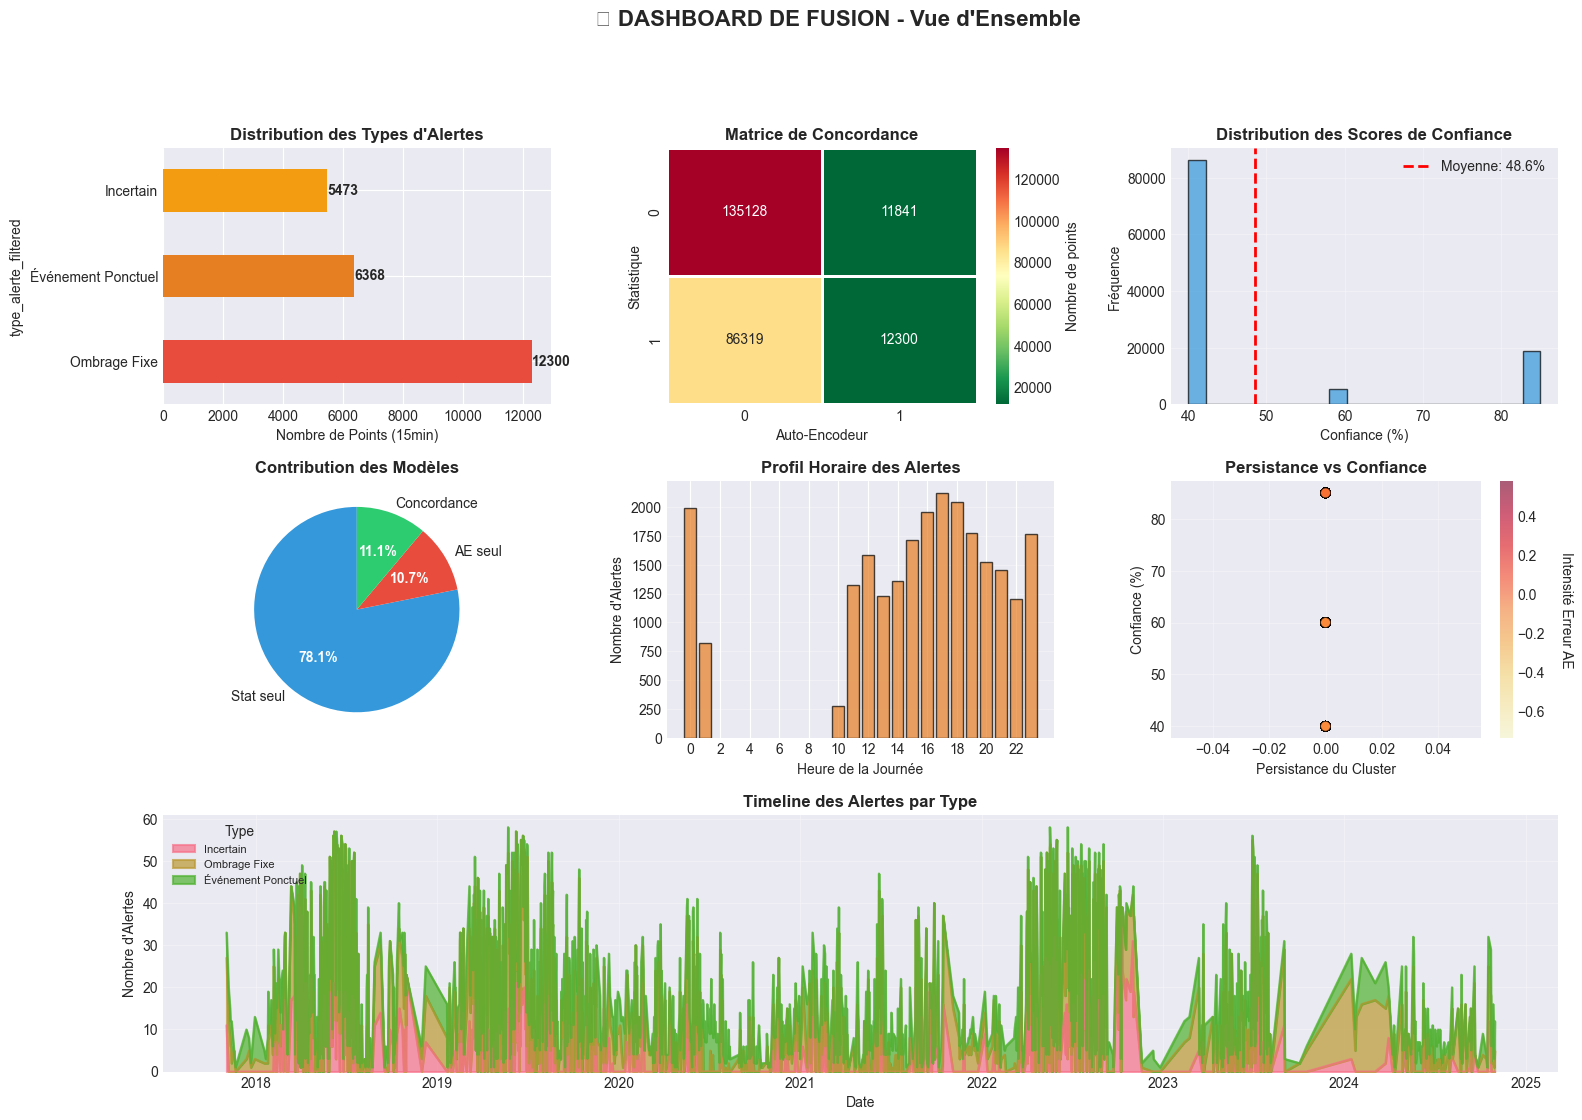

In [7]:
# ==================== VISUALISATIONS DE LA FUSION ====================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

# Configuration style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n" + "="*70)
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("="*70)

# ==================== FIGURE 1 : DASHBOARD GLOBAL ====================
fig1 = plt.figure(figsize=(18, 12))
gs = fig1.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1.1 - Distribution des types d'alertes
ax1 = fig1.add_subplot(gs[0, 0])
alert_counts = df_master['type_alerte_filtered'].value_counts()
alert_counts = alert_counts[alert_counts.index != 'Normal']  # Exclure Normal
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#9b59b6']
alert_counts.plot(kind='barh', ax=ax1, color=colors[:len(alert_counts)])
ax1.set_title('Distribution des Types d\'Alertes', fontsize=12, fontweight='bold')
ax1.set_xlabel('Nombre de Points (15min)')
for i, v in enumerate(alert_counts.values):
    ax1.text(v + 5, i, str(v), va='center', fontweight='bold')

# 1.2 - Concordance Stat vs AE (Matrice de confusion)
ax2 = fig1.add_subplot(gs[0, 1])
confusion = pd.crosstab(
    df_master['anomaly_detected'], 
    df_master['anomaly_ae'],
    rownames=['Statistique'],
    colnames=['Auto-Encodeur']
)
sns.heatmap(confusion, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax2, 
            cbar_kws={'label': 'Nombre de points'}, linewidths=1, linecolor='white')
ax2.set_title('Matrice de Concordance', fontsize=12, fontweight='bold')

# 1.3 - Distribution des scores de confiance
ax3 = fig1.add_subplot(gs[0, 2])
conf_data = df_master[df_master['confiance'] > 0]['confiance']
ax3.hist(conf_data, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax3.axvline(conf_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {conf_data.mean():.1f}%')
ax3.set_title('Distribution des Scores de Confiance', fontsize=12, fontweight='bold')
ax3.set_xlabel('Confiance (%)')
ax3.set_ylabel('Fréquence')
ax3.legend()
ax3.grid(alpha=0.3)

# 1.4 - Contribution des modèles (Venn-like)
ax4 = fig1.add_subplot(gs[1, 0])
stat_only = ((df_master['anomaly_detected'] == 1) & (df_master['anomaly_ae'] == 0)).sum()
ae_only = ((df_master['anomaly_detected'] == 0) & (df_master['anomaly_ae'] == 1)).sum()
both = df_master['feat_concordance'].sum()
contribution = pd.Series({
    'Stat seul': stat_only,
    'AE seul': ae_only,
    'Concordance': both
})
colors_venn = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax4.pie(contribution, labels=contribution.index, autopct='%1.1f%%',
                                     colors=colors_venn, startangle=90, textprops={'fontsize': 10})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax4.set_title('Contribution des Modèles', fontsize=12, fontweight='bold')

# 1.5 - Profil horaire des alertes
ax5 = fig1.add_subplot(gs[1, 1])
hourly_alerts = df_master[df_master['type_alerte_filtered'] != 'Normal'].groupby('feat_hour_of_day').size()
ax5.bar(hourly_alerts.index, hourly_alerts.values, color='#e67e22', alpha=0.7, edgecolor='black')
ax5.set_title('Profil Horaire des Alertes', fontsize=12, fontweight='bold')
ax5.set_xlabel('Heure de la Journée')
ax5.set_ylabel('Nombre d\'Alertes')
ax5.set_xticks(range(0, 24, 2))
ax5.grid(alpha=0.3, axis='y')

# 1.6 - Persistance vs Confiance (Scatter)
ax6 = fig1.add_subplot(gs[1, 2])
scatter_data = df_master[df_master['confiance'] > 0]
scatter = ax6.scatter(scatter_data['feat_persistance_cluster'], 
                      scatter_data['confiance'],
                      c=scatter_data['feat_error_intensity'], 
                      cmap='YlOrRd', 
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax6.set_title('Persistance vs Confiance', fontsize=12, fontweight='bold')
ax6.set_xlabel('Persistance du Cluster')
ax6.set_ylabel('Confiance (%)')
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Intensité Erreur AE', rotation=270, labelpad=20)
ax6.grid(alpha=0.3)

# 1.7 - Timeline des événements (par type)
ax7 = fig1.add_subplot(gs[2, :])
df_master['date'] = pd.to_datetime(df_master['timestamp']).dt.date

# Compter alertes par jour et par type
daily_alerts = df_master[df_master['type_alerte_filtered'] != 'Normal'].groupby(
    ['date', 'type_alerte_filtered']
).size().unstack(fill_value=0)

if not daily_alerts.empty:
    daily_alerts.plot(kind='area', stacked=True, ax=ax7, alpha=0.7, linewidth=1.5)
    ax7.set_title('Timeline des Alertes par Type', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Nombre d\'Alertes')
    ax7.legend(title='Type', loc='upper left', fontsize=8)
    ax7.grid(alpha=0.3)
else:
    ax7.text(0.5, 0.5, 'Aucune alerte détectée', ha='center', va='center', fontsize=14)

plt.suptitle('🔍 DASHBOARD DE FUSION - Vue d\'Ensemble', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('fusion_dashboard_global.png', dpi=300, bbox_inches='tight')
print("💾 fusion_dashboard_global.png")

C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3511644592.py:81: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3511644592.py:82: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('fusion_timeline_detailed.png', dpi=300, bbox_inches='tight')


💾 fusion_timeline_detailed.png


C:\Users\Claire\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


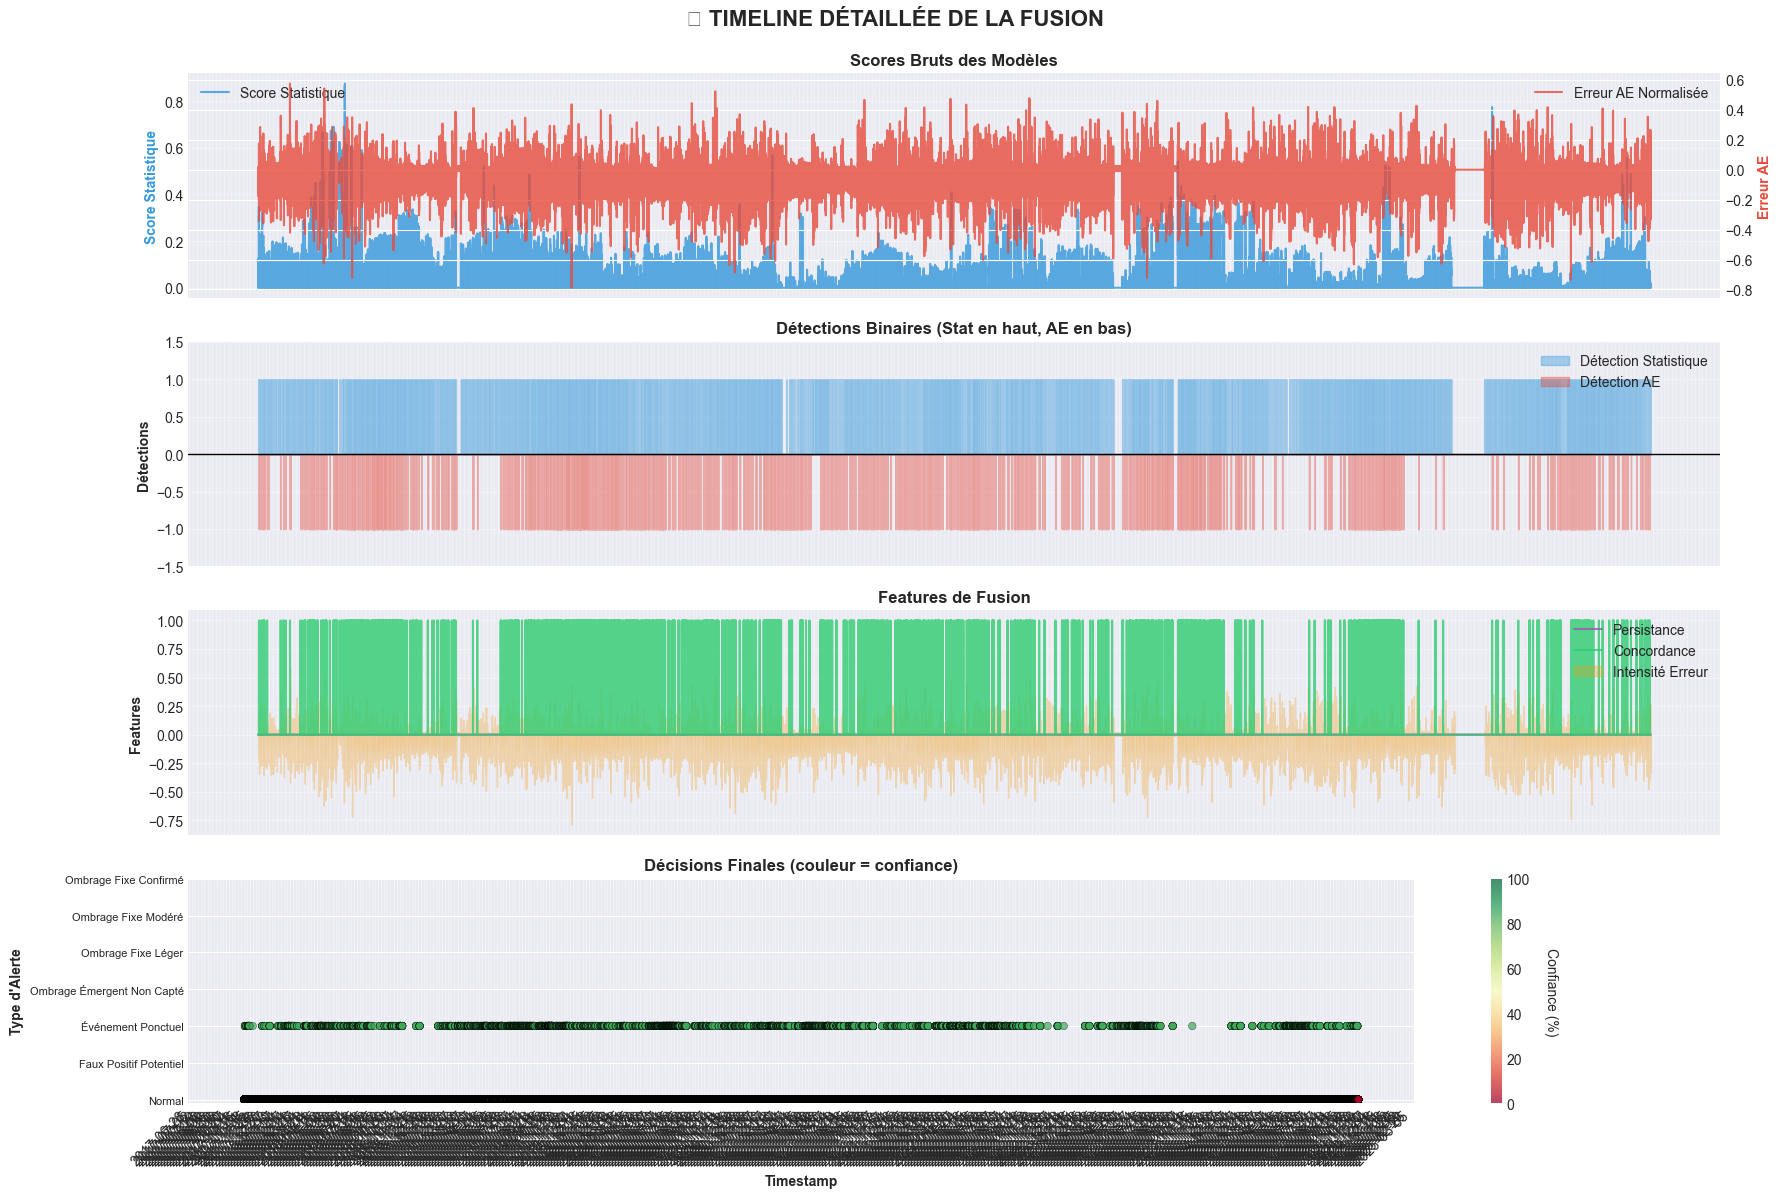

In [8]:
fig2, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# Préparer les données
df_plot = df_master.set_index('timestamp').sort_index()

# 2.1 - Scores bruts des deux modèles
ax_scores = axes[0]
ax_scores.plot(df_plot.index, df_plot['shadow_score'], 
               label='Score Statistique', color='#3498db', linewidth=1.5, alpha=0.8)
ax_ae = ax_scores.twinx()
ax_ae.plot(df_plot.index, df_plot['error_normalized'], 
           label='Erreur AE Normalisée', color='#e74c3c', linewidth=1.5, alpha=0.8)
ax_scores.set_ylabel('Score Statistique', color='#3498db', fontweight='bold')
ax_ae.set_ylabel('Erreur AE', color='#e74c3c', fontweight='bold')
ax_scores.set_title('Scores Bruts des Modèles', fontsize=12, fontweight='bold')
ax_scores.legend(loc='upper left')
ax_ae.legend(loc='upper right')
ax_scores.grid(alpha=0.3)

# 2.2 - Détections binaires
ax_detections = axes[1]
ax_detections.fill_between(df_plot.index, 0, df_plot['anomaly_detected'], 
                            alpha=0.4, color='#3498db', label='Détection Statistique', step='mid')
ax_detections.fill_between(df_plot.index, 0, -df_plot['anomaly_ae'], 
                            alpha=0.4, color='#e74c3c', label='Détection AE', step='mid')
ax_detections.set_ylabel('Détections', fontweight='bold')
ax_detections.set_title('Détections Binaires (Stat en haut, AE en bas)', fontsize=12, fontweight='bold')
ax_detections.set_ylim(-1.5, 1.5)
ax_detections.axhline(0, color='black', linewidth=1)
ax_detections.legend(loc='upper right')
ax_detections.grid(alpha=0.3)

# 2.3 - Features de fusion
ax_features = axes[2]
ax_features.plot(df_plot.index, df_plot['feat_persistance_cluster'], 
                 label='Persistance', color='#9b59b6', linewidth=1.5, alpha=0.8)
ax_features.plot(df_plot.index, df_plot['feat_concordance'], 
                 label='Concordance', color='#2ecc71', linewidth=1.5, alpha=0.8)
ax_features.fill_between(df_plot.index, 0, df_plot['feat_error_intensity'], 
                         alpha=0.3, color='#f39c12', label='Intensité Erreur')
ax_features.set_ylabel('Features', fontweight='bold')
ax_features.set_title('Features de Fusion', fontsize=12, fontweight='bold')
ax_features.legend(loc='upper right')
ax_features.grid(alpha=0.3)

# 2.4 - Décisions finales avec confiance
ax_final = axes[3]
# Mapper les types à des valeurs numériques pour affichage
type_mapping = {
    'Normal': 0,
    'Faux Positif Potentiel': 1,
    'Événement Ponctuel': 2,
    'Ombrage Émergent Non Capté': 3,
    'Ombrage Fixe Léger': 4,
    'Ombrage Fixe Modéré': 5,
    'Ombrage Fixe Confirmé': 6
}
df_plot['type_numeric'] = df_plot['type_alerte_filtered'].map(type_mapping)

# Créer un scatter avec couleur = confiance
scatter = ax_final.scatter(df_plot.index, df_plot['type_numeric'], 
                           c=df_plot['confiance'], cmap='RdYlGn', 
                           s=30, alpha=0.7, edgecolors='black', linewidth=0.3,
                           vmin=0, vmax=100)
ax_final.set_ylabel('Type d\'Alerte', fontweight='bold')
ax_final.set_yticks(list(type_mapping.values()))
ax_final.set_yticklabels(list(type_mapping.keys()), fontsize=8)
ax_final.set_title('Décisions Finales (couleur = confiance)', fontsize=12, fontweight='bold')
ax_final.set_xlabel('Timestamp', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax_final)
cbar.set_label('Confiance (%)', rotation=270, labelpad=20)
ax_final.grid(alpha=0.3, axis='x')

# Formatter l'axe des dates
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('📈 TIMELINE DÉTAILLÉE DE LA FUSION', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('fusion_timeline_detailed.png', dpi=300, bbox_inches='tight')
print("💾 fusion_timeline_detailed.png")

C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3221249609.py:20: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3221249609.py:20: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3221249609.py:21: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) Arial.
  plt.savefig('fusion_heatmap_temporal.png', dpi=300, bbox_inches='tight')
C:\Users\Claire\AppData\Local\Temp\ipykernel_22768\3221249609.py:21: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('fusion_heatmap_temporal.png', dpi=300, bbox_inches='tight')


💾 fusion_heatmap_temporal.png


C:\Users\Claire\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Claire\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


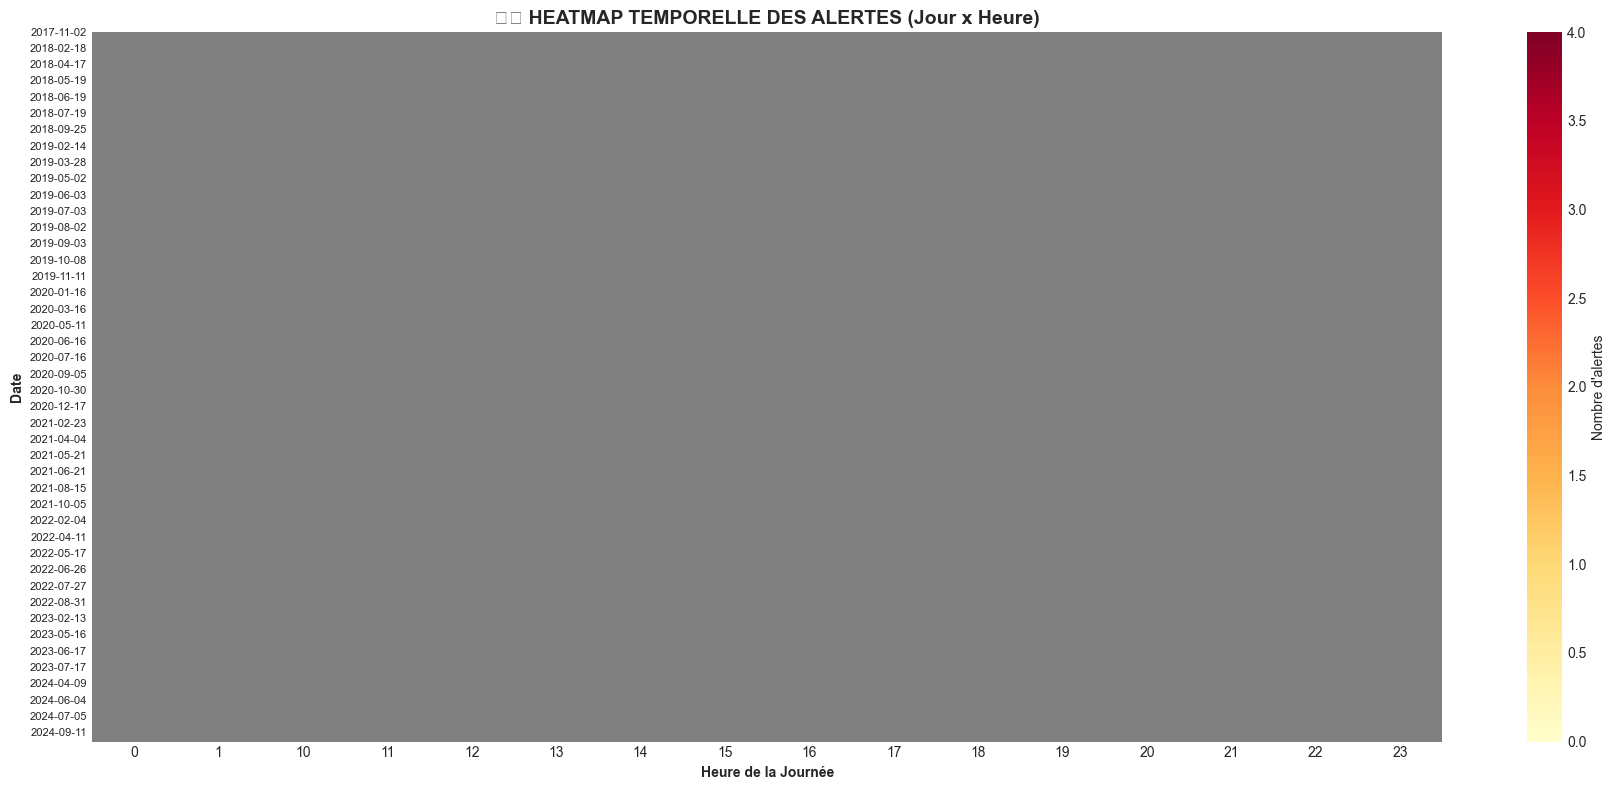

In [9]:
fig4, ax4 = plt.subplots(figsize=(18, 8))

# Créer matrice jour x heure
df_heatmap = df_master[df_master['type_alerte_filtered'] != 'Normal'].copy()
df_heatmap['date'] = pd.to_datetime(df_heatmap['timestamp']).dt.date
df_heatmap['hour'] = pd.to_datetime(df_heatmap['timestamp']).dt.hour

heatmap_data = df_heatmap.groupby(['date', 'hour']).size().unstack(fill_value=0)

if not heatmap_data.empty:
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Nombre d\'alertes'}, 
                linewidths=0.5, linecolor='gray')
    ax4.set_title('🗓️ HEATMAP TEMPORELLE DES ALERTES (Jour x Heure)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Heure de la Journée', fontweight='bold')
    ax4.set_ylabel('Date', fontweight='bold')
    ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=8)
else:
    ax4.text(0.5, 0.5, 'Aucune alerte à afficher', ha='center', va='center', fontsize=14, transform=ax4.transAxes)

plt.tight_layout()
plt.savefig('fusion_heatmap_temporal.png', dpi=300, bbox_inches='tight')
print("💾 fusion_heatmap_temporal.png")